<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:


Saving meuse.txt to meuse (3).txt

[INFO] Total data valid dimuat: 155 baris observasi.

 1. ANALISIS STATISTIK DESKRIPTIF (ZINC & COPPER)
        Count        Mean         Std    Min  Median     Max
zinc    155.0  469.716129  367.073788  113.0   326.0  1839.0
copper  155.0   40.316129   23.680436   14.0    31.0   128.0

 2. MATRIKS KORELASI PEARSON (LOG-ZINC & LOG-COPPER)
            log_zinc  log_copper
log_zinc    1.000000    0.897151
log_copper  0.897151    1.000000

[INFO] Menghasilkan Visualisasi EDA & Sebaran Awal...


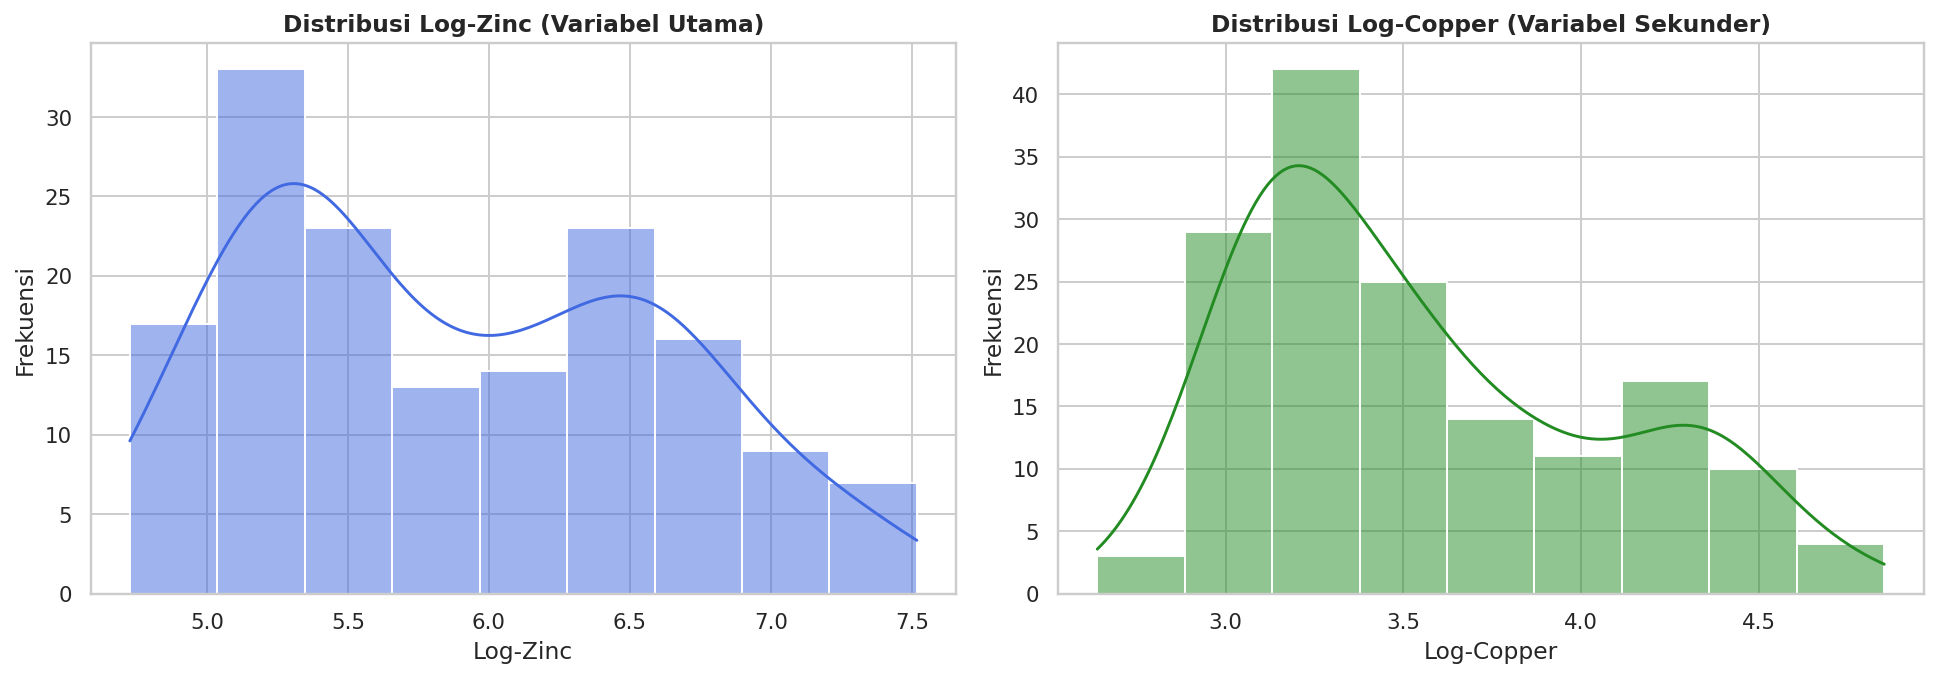

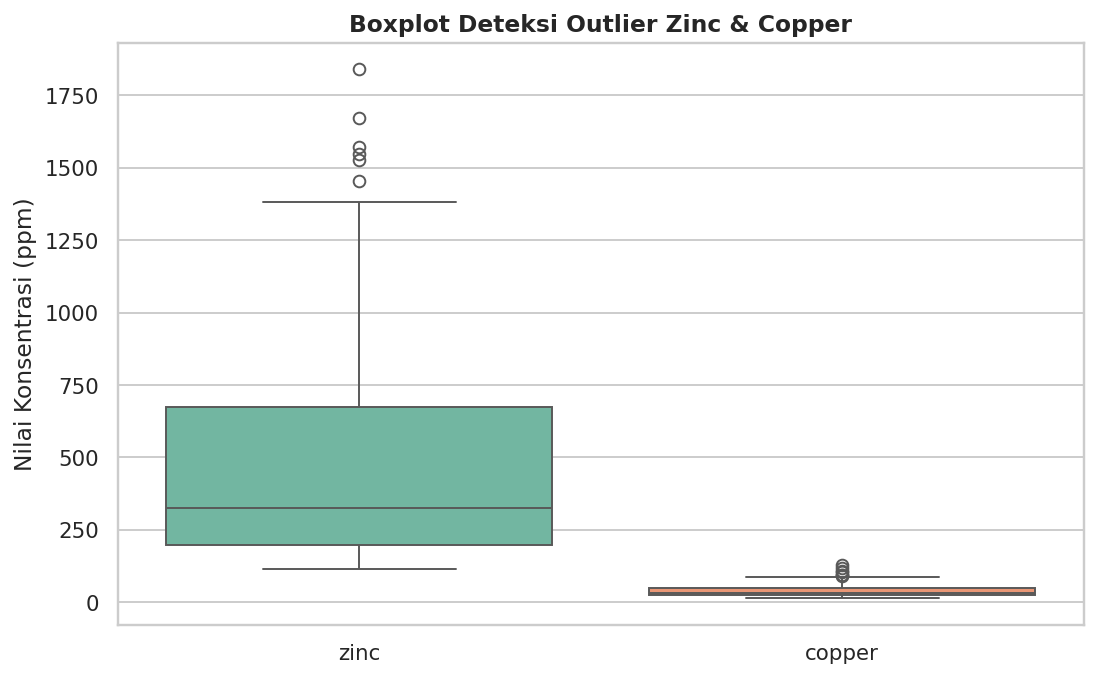

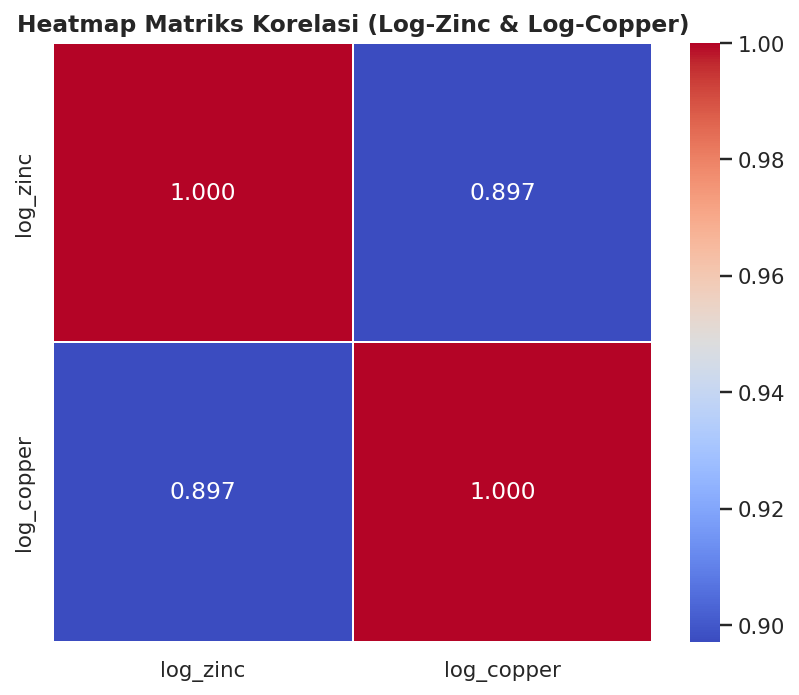

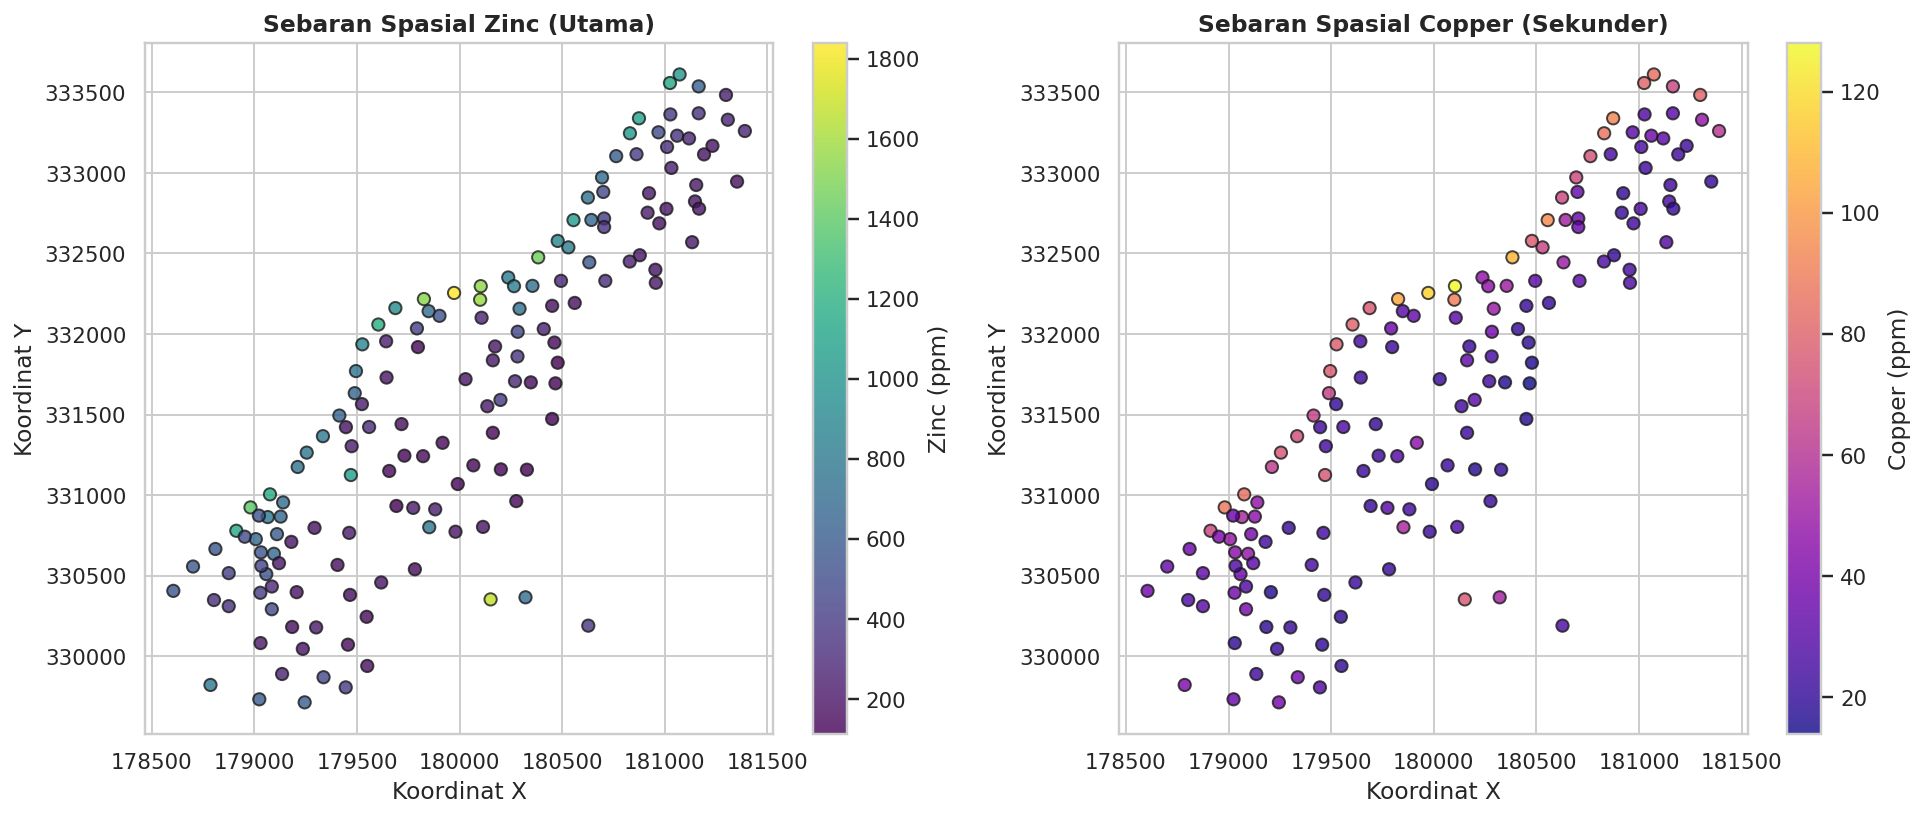

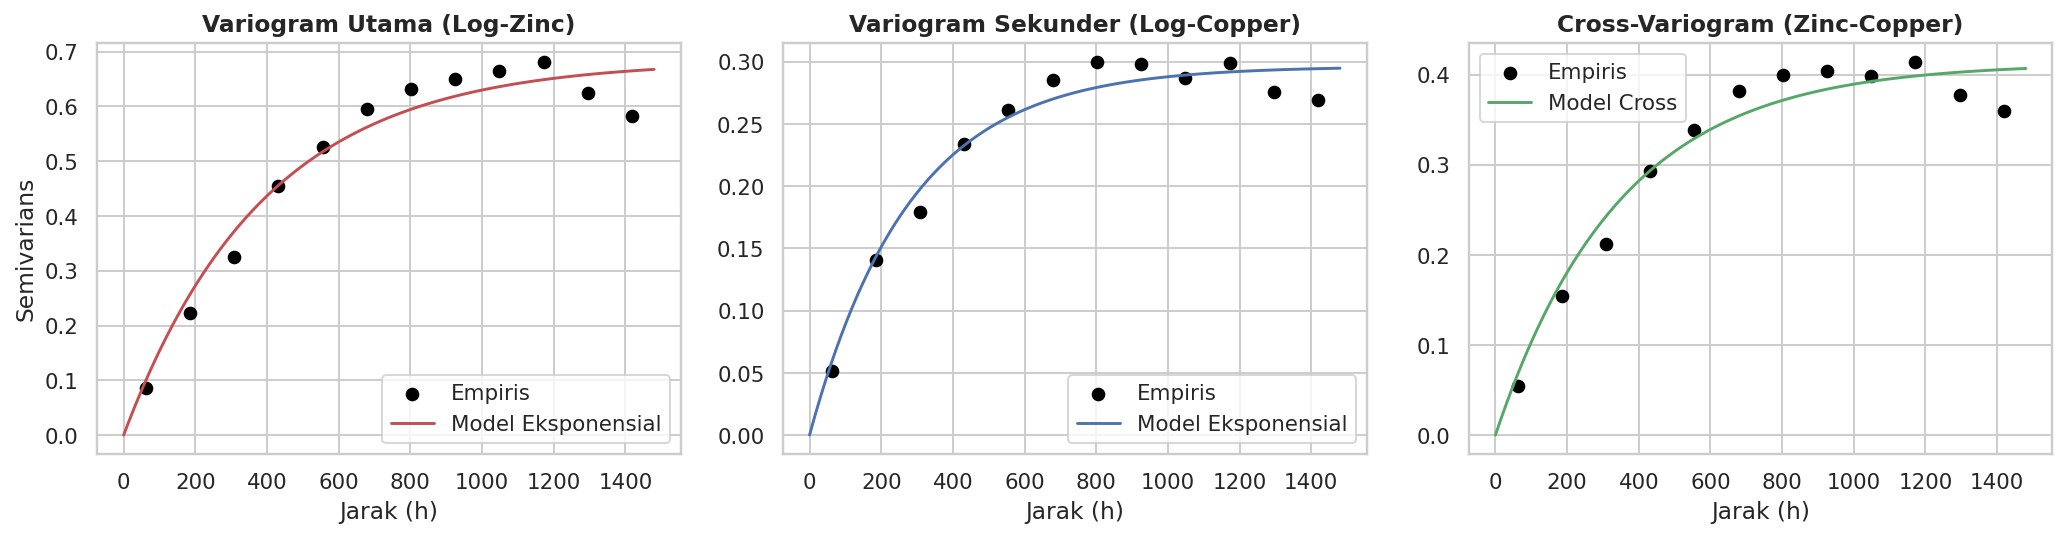


[INFO] Menjalankan Validasi Silang (LOOCV) Co-Kriging...

 HASIL EVALUASI VALIDASI SILANG CO-KRIGING
 RMSE (Skala Log) : 0.3971
 R-Squared (R²)   : 0.6955
[INFO] Membangun Grid Peta Interpolasi Co-Kriging & Ketidakpastian...


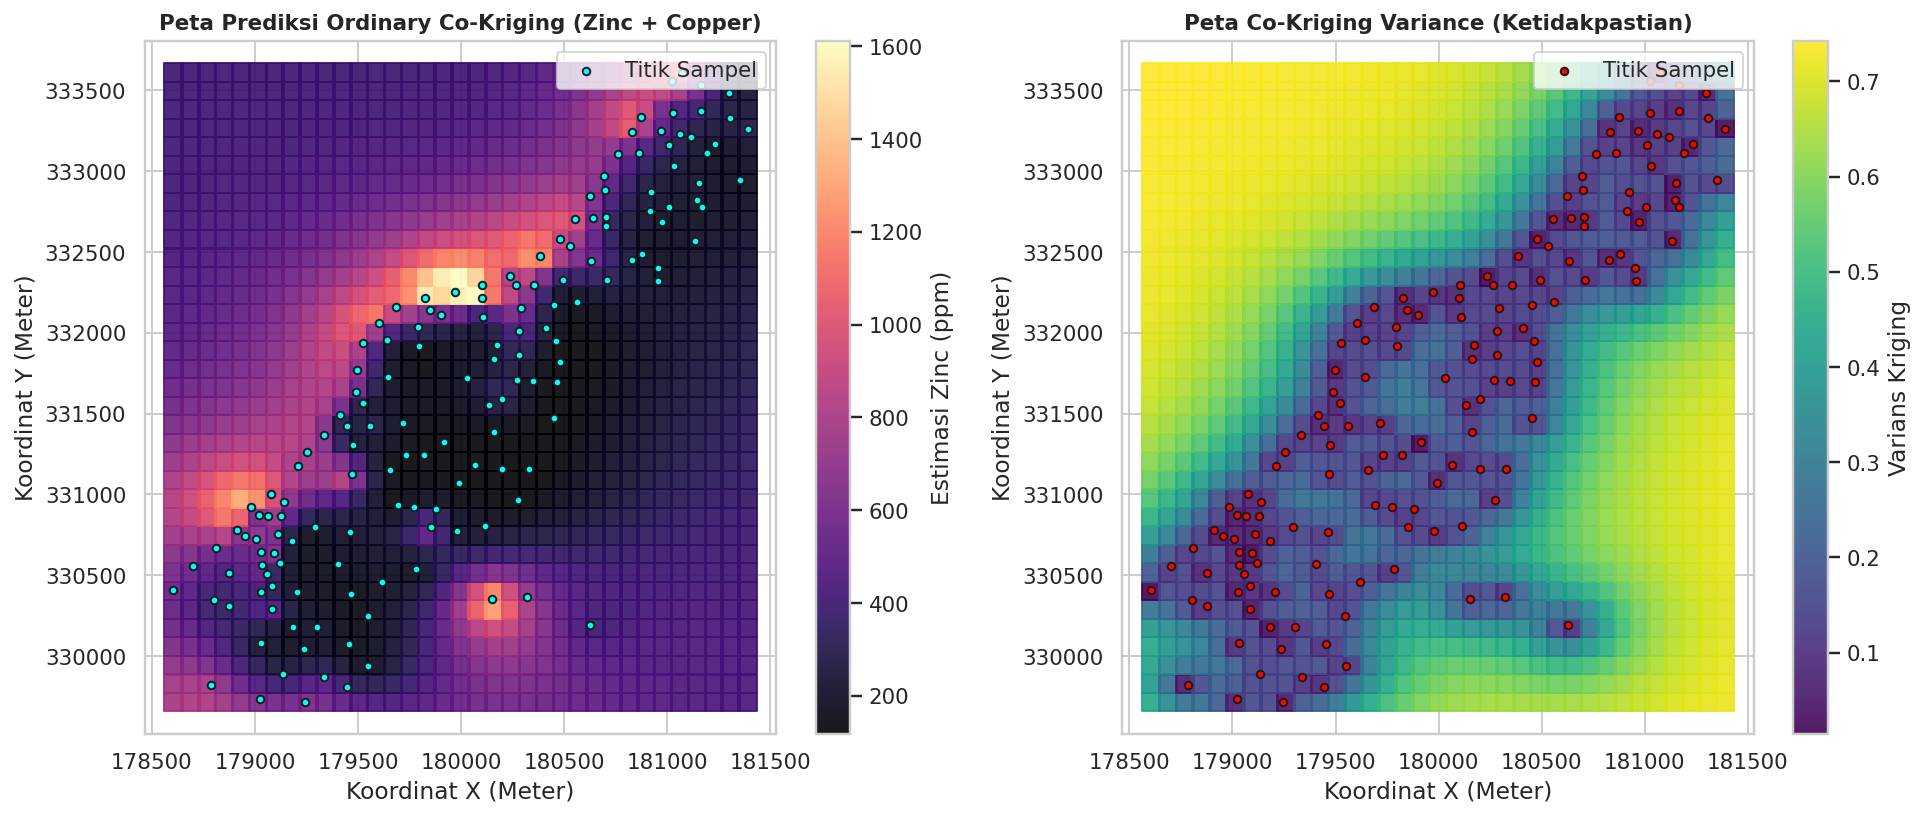

In [6]:
# ==============================================================================
# MASTER SCRIPT FINAL, BERSIH, & LENGKAP: ORDINARY CO-KRIGING (ZINC & COPPER)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pengaturan Tema Visualisasi Akademik
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

# ==============================================================================
# TAHAP 1: UPLOAD DATA & STATISTIK DESKRIPTIF (EDA)
# ==============================================================================
print("Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_meuse = pd.read_csv(filename).dropna(subset=['zinc', 'copper'])

print(f"\n[INFO] Total data valid dimuat: {len(df_meuse)} baris observasi.")

# A. Statistik Deskriptif (Zinc & Copper)
print("\n" + "="*60)
print(" 1. ANALISIS STATISTIK DESKRIPTIF (ZINC & COPPER)")
print("="*60)
desc_table = df_meuse[['zinc', 'copper']].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
desc_table.columns = ['Count', 'Mean', 'Std', 'Min', 'Median', 'Max']
print(desc_table.to_string())
print("="*60)

# B. Transformasi Log-Natural
df_meuse['log_zinc'] = np.log(df_meuse['zinc'])
df_meuse['log_copper'] = np.log(df_meuse['copper'])

# C. Matriks Korelasi Pearson (Log-Zinc & Log-Copper)
print("\n" + "="*60)
print(" 2. MATRIKS KORELASI PEARSON (LOG-ZINC & LOG-COPPER)")
print("="*60)
corr_matrix_table = df_meuse[['log_zinc', 'log_copper']].corr()
print(corr_matrix_table.to_string())
print("="*60)

# ==============================================================================
# TAHAP 2: VISUALISASI EDA & SEBARAN SPASIAL AWAL
# ==============================================================================
print("\n[INFO] Menghasilkan Visualisasi EDA & Sebaran Awal...")

# A. Histogram & KDE Log-Zinc & Log-Copper
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_meuse['log_zinc'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribusi Log-Zinc (Variabel Utama)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log-Zinc')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df_meuse['log_copper'], kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Distribusi Log-Copper (Variabel Sekunder)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log-Copper')
axes[1].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# B. Boxplot Deteksi Outlier
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_meuse[['zinc', 'copper']], palette='Set2')
plt.title('Boxplot Deteksi Outlier Zinc & Copper', fontsize=12, fontweight='bold')
plt.ylabel('Nilai Konsentrasi (ppm)')
plt.tight_layout()
plt.show()

# C. Heatmap Matriks Korelasi
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix_table, annot=True, cmap='coolwarm', fmt='.3f', linewidths=1, cbar=True, square=True)
plt.title('Heatmap Matriks Korelasi (Log-Zinc & Log-Copper)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# D. Peta Sebaran Spasial Titik Sampel (Zinc & Copper)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc1 = axes[0].scatter(df_meuse['x'], df_meuse['y'], c=df_meuse['zinc'], cmap='viridis', s=40, edgecolors='k', alpha=0.8)
fig.colorbar(sc1, ax=axes[0], label='Zinc (ppm)')
axes[0].set_title('Sebaran Spasial Zinc (Utama)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Koordinat X')
axes[0].set_ylabel('Koordinat Y')

sc2 = axes[1].scatter(df_meuse['x'], df_meuse['y'], c=df_meuse['copper'], cmap='plasma', s=40, edgecolors='k', alpha=0.8)
fig.colorbar(sc2, ax=axes[1], label='Copper (ppm)')
axes[1].set_title('Sebaran Spasial Copper (Sekunder)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Koordinat X')
axes[1].set_ylabel('Koordinat Y')
plt.tight_layout()
plt.show()

# ==============================================================================
# TAHAP 3: VARIOGRAM EMPIRIS & CROSS-VARIOGRAM
# ==============================================================================
coords = df_meuse[['x', 'y']].values
z1 = df_meuse['log_zinc'].values
z2 = df_meuse['log_copper'].values

def compute_variogram(coords, z_a, z_b=None, n_lags=12, max_dist=None):
    dist_matrix = squareform(pdist(coords))
    if max_dist is None:
        max_dist = np.max(dist_matrix) / 3.0
    bins = np.linspace(0, max_dist, n_lags + 1)
    lags = 0.5 * (bins[:-1] + bins[1:])
    gamma_emp = []

    for i in range(n_lags):
        mask = (dist_matrix >= bins[i]) & (dist_matrix < bins[i+1])
        if np.sum(mask) > 0:
            dz_a = z_a[:, None] - z_a[None, :]
            if z_b is None:
                g = 0.5 * np.mean((dz_a[mask])**2)
            else:
                dz_b = z_b[:, None] - z_b[None, :]
                g = 0.5 * np.mean(dz_a[mask] * dz_b[mask])
            gamma_emp.append(g)
        else:
            gamma_emp.append(np.nan)
    return lags, np.array(gamma_emp)

max_d = np.max(pdist(coords)) / 3.0
lags, g_z1 = compute_variogram(coords, z1, max_dist=max_d)
lags, g_z2 = compute_variogram(coords, z2, max_dist=max_d)
lags, g_cross = compute_variogram(coords, z1, z2, max_dist=max_d)

# ==============================================================================
# TAHAP 4: FITTING MODEL TEORETIS & VISUALISASI VARIOGRAM
# ==============================================================================
def theoretical_model(h, c0, c, a):
    h = np.asarray(h)
    return c0 + c * (1.0 - np.exp(-h / a))

def fit_model(lags, gamma_emp):
    def loss(params):
        c0, c, a = params
        if c0 < 0 or c < 0 or a <= 0:
            return 1e9
        pred = theoretical_model(lags, c0, c, a)
        valid = ~np.isnan(gamma_emp)
        return np.sum((gamma_emp[valid] - pred[valid])**2)
    res = minimize(loss, [np.nanmin(gamma_emp), np.nanmax(gamma_emp)-np.nanmin(gamma_emp), max_d/2],
                   bounds=[(1e-4, None), (1e-4, None), (10, max_d*2)], method='L-BFGS-B')
    return res.x

p_11 = fit_model(lags, g_z1)
p_22 = fit_model(lags, g_z2)
p_12 = fit_model(lags, g_cross)

# Visualisasi Fitting Variogram & Cross-Variogram
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(lags, g_z1, label='Empiris', color='black')
h_plot = np.linspace(0, max_d, 100)
plt.plot(h_plot, theoretical_model(h_plot, *p_11), 'r-', label='Model Eksponensial')
plt.title('Variogram Utama (Log-Zinc)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.ylabel('Semivarians')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(lags, g_z2, label='Empiris', color='black')
plt.plot(h_plot, theoretical_model(h_plot, *p_22), 'b-', label='Model Eksponensial')
plt.title('Variogram Sekunder (Log-Copper)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(lags, g_cross, label='Empiris', color='black')
plt.plot(h_plot, theoretical_model(h_plot, *p_12), 'g-', label='Model Cross')
plt.title('Cross-Variogram (Zinc-Copper)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# TAHAP 5: FUNGSI SISTEM ORDINARY CO-KRIGING
# ==============================================================================
def co_krig_predict_single(coords, z1, z2, target_coord):
    n = len(coords)
    D = squareform(pdist(coords))

    G11 = theoretical_model(D, *p_11)
    G22 = theoretical_model(D, *p_22)
    G12 = theoretical_model(D, *p_12)

    sz = 2 * n + 2
    K = np.zeros((sz, sz))

    K[:n, :n] = G11
    K[:n, n:2*n] = G12
    K[n:2*n, :n] = G12.T
    K[n:2*n, n:2*n] = G22

    K[:n, 2*n] = 1.0
    K[2*n, :n] = 1.0
    K[n:2*n, 2*n+1] = 1.0
    K[2*n+1, n:2*n] = 1.0

    dt = np.sqrt(np.sum((coords - target_coord)**2, axis=1))

    k0 = np.zeros(sz)
    k0[:n] = theoretical_model(dt, *p_11)
    k0[n:2*n] = theoretical_model(dt, *p_12)
    k0[2*n] = 1.0
    k0[2*n+1] = 0.0

    try:
        K_stable = K.copy()
        np.fill_diagonal(K_stable[:2*n, :2*n], K_stable.diagonal()[:2*n] + 1e-5)

        weights = np.linalg.solve(K_stable, k0)
        lam1 = weights[:n]
        lam2 = weights[n:2*n]
        m1 = weights[2*n]

        log_pred = np.sum(lam1 * z1) + np.sum(lam2 * z2)
        variance = np.sum(lam1 * k0[:n]) + np.sum(lam2 * k0[n:2*n]) + m1
        return np.exp(log_pred), log_pred, max(0, variance)
    except:
        return np.exp(np.mean(z1)), np.mean(z1), 0.0

# ==============================================================================
# TAHAP 6: VALIDASI SILANG (LOOCV) & EVALUASI
# ==============================================================================
print("\n[INFO] Menjalankan Validasi Silang (LOOCV) Co-Kriging...")
y_true_log = z1
y_pred_log = []

for i in range(len(coords)):
    mask = np.ones(len(coords), dtype=bool)
    mask[i] = False
    _, l_pred, _ = co_krig_predict_single(coords[mask], z1[mask], z2[mask], coords[i])
    y_pred_log.append(l_pred)

y_pred_log = np.array(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2 = r2_score(y_true_log, y_pred_log)

print("\n" + "="*50)
print(" HASIL EVALUASI VALIDASI SILANG CO-KRIGING")
print("="*50)
print(f" RMSE (Skala Log) : {rmse:.4f}")
print(f" R-Squared (R²)   : {r2:.4f}")
print("="*50)

# ==============================================================================
# TAHAP 7: PEMETAAN SPASIAL AKHIR CO-KRIGING
# ==============================================================================
print("[INFO] Membangun Grid Peta Interpolasi Co-Kriging & Ketidakpastian...")
grid_x = np.linspace(df_meuse['x'].min(), df_meuse['x'].max(), 35)
grid_y = np.linspace(df_meuse['y'].min(), df_meuse['y'].max(), 35)
GX, GY = np.meshgrid(grid_x, grid_y)
G_coords = np.c_[GX.ravel(), GY.ravel()]

preds_original = []
co_krig_vars = []

for pt in G_coords:
    p_orig, _, var = co_krig_predict_single(coords, z1, z2, pt)
    preds_original.append(p_orig)
    co_krig_vars.append(var)

# Visualisasi Peta Prediksi & Varians Akhir
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(G_coords[:, 0], G_coords[:, 1], c=preds_original, cmap='magma', s=90, marker='s', alpha=0.9)
axes[0].scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Titik Sampel')
axes[0].set_title('Peta Prediksi Ordinary Co-Kriging (Zinc + Copper)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Koordinat X (Meter)')
axes[0].set_ylabel('Koordinat Y (Meter)')
axes[0].legend(loc='upper right')
fig.colorbar(sc1, ax=axes[0], label='Estimasi Zinc (ppm)')

sc2 = axes[1].scatter(G_coords[:, 0], G_coords[:, 1], c=co_krig_vars, cmap='viridis', s=90, marker='s', alpha=0.9)
axes[1].scatter(df_meuse['x'], df_meuse['y'], c='red', s=15, edgecolors='k', label='Titik Sampel')
axes[1].set_title('Peta Co-Kriging Variance (Ketidakpastian)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Koordinat X (Meter)')
axes[1].set_ylabel('Koordinat Y (Meter)')
axes[1].legend(loc='upper right')
fig.colorbar(sc2, ax=axes[1], label='Varians Kriging')

plt.tight_layout()
plt.show()